# 00_intro — Emulator Edition

This is a re-working of `00_intro.ipynb` that targets the QICK emulator instead of a live board.
Each section defines the same QICK programs as the original notebook, but instead of calling
`prog.acquire_decimated(soc, ...)` the notebook calls `emu.prepare()` + `emu.export_vivado_files()`
to generate the artifact set needed to run in:
- **Vivado / xsim** — via `tb_qick_emu.sv`
- **Verilator** — via `tb_qick_emu_verilator` (full-system testbench)

Artifacts written per program:
- `pmem.mem` — tProc program memory
- `wmem.mem` — tProc waveform parameter table
- `sgmem_ch{N}.mem` — signal-generator envelope tables (shaped pulses only)
- `axi_replay.jsonl` — raw AXI-Lite transaction log
- `axi_replay.txt` — flat hex format for the Verilator/Vivado TBs

The notebook can also **run the Verilator simulation and plot results inline** —
see the "Simulate & Plot" sections after each program.

No board required.

## Setup

In [1]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── path setup ────────────────────────────────────────────────────────────────
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
source_dir = REPO_ROOT / 'software' / 'source'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import qick_emu
importlib.reload(qick_emu)          # pick up edits without kernel restart
from qick_emu import QickEmu

from qick.asm_v2 import AveragerProgramV2, QickSpan, QickSweep1D

# ── emulator init ─────────────────────────────────────────────────────────────
CFG_PATH = REPO_ROOT / 'notebooks' / 'qick_config_216.json'
emu      = QickEmu(str(CFG_PATH))
soccfg   = emu.soccfg

# ── artifact root ─────────────────────────────────────────────────────────────
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '00_intro'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

/Users/sbf/projects/qick-env/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
QICK library version mismatch: 0.2.366 remote (the board), 0.2.370 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


REPO_ROOT     : /Users/sbf/Desktop/to_verilate/emulator
ARTIFACTS_ROOT: /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro
QICK running on ZCU216, software version 0.2.366

Firmware configuration (built Sat Sep 28 22:15:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-bit DD

In [2]:
# ZCU216 standard firmware channel assignments
GEN_CH    = 0
RO_CH     = 0
TRIG_TIME = 0.40   # us
FREQ      = 100    # MHz

---
## basic multi-pulse program

Just a "reps" loop, no sweeping — like v1 AveragerProgram.

In v2, you define all of your pulses up front, then play them as needed.
Contrast to v1, where only one pulse could be defined per generator at a time.

In [3]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.2
        self.add_gauss(ch=gen_ch, name='ramp', sigma=ramp_len/10,
                       length=ramp_len, even_length=True)

        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='mygaus', ro_ch=ro_ch,
                       style='arb', envelope='ramp',
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myconst', ro_ch=ro_ch,
                       style='const', length=0.2,
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myflattop2', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=90, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name='myflattop',  t=0)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=0.4)
        self.pulse(ch=cfg['gen_ch'], name='myconst',    t=0.8)
        self.pulse(ch=cfg['gen_ch'], name='myflattop2', t=1.2)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=1.6)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    1.9,
}

prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# ── generate emulator artifacts ───────────────────────────────────────────────
OUT = ARTIFACTS_ROOT / 'multi_pulse'
OUT.mkdir(parents=True, exist_ok=True)

soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

print(f'\nArtifacts → {OUT}')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name:<25s}  {f.stat().st_size:>8d} bytes')

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------


Artifacts → /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse
  axi_replay.jsonl                644 bytes
  axi_replay.txt                  440 bytes
  dmem.mem                          9 bytes
  pmem.mem                        529 bytes
  sgmem_ch0.mem                 12137 bytes
  wmem.mem                        499 bytes


### Simulate & plot (MultiPulse)

Run the Verilator full-system TB and plot the DAC/readout outputs inline.
Set `RUN_SIM = False` to skip if Verilator is not installed.

[verilate] Building tb_qick_emu_verilator ...
verilator --binary --exe --build -j 0 -Wall --trace-vcd --Wno-fatal --timing -Wno-DECLFILENAME -Wno-PINCONNECTEMPTY -Wno-VARHIDDEN -Wno-TIMESCALEMOD -Wno-EOFNEWLINE -Wno-WIDTH -Wno-PINMISSING -Wno-BADVLTPRAGMA -Wno-CONSTRAINTIGN -I../../../firmware/pulp_platform/axi/include -I../../../firmware/pulp_platform/common_verification/include -I../../../firmware/pulp_platform/common_cells/include -I../../../firmware/ip/qick_processor/src -y ../../../emulator/models/bram_dp -y ../../../emulator/models/fifo -y ../../../emulator/models/dac_model -y ../../../emulator/models/sig_gen_dds -y ../../../emulator/models/sig_gen_dds/src -y ../../../firmware/ip/common -y ../../../firmware/ip/qick_common  verilator.vlt --top-module tb_qick_emu_verilator ../../../firmware/ip/axis_signal_gen_v6/src/axis_signal_gen_v6.v ../../../firmware/ip/axis_signal_gen_v6/src/latency_reg.v ../../../firmware/ip/axis_signal_gen_v6/src/signal_gen.v ../../../firmware/ip/axis_signal

%Warning-DEFOVERRIDE: ../../../emulator/models/bram_dp/../../../firmware/ip/qick_processor/src/_qproc_ips.sv:31:1: Overriding define: 'VERILATOR' with value: '' to existing command line define value: '1'
                      ... Location of previous definition, with value: '1'
                      ... For warning description see https://verilator.org/warn/DEFOVERRIDE?v=5.038
                      ... Use "/* verilator lint_off DEFOVERRIDE */" and lint_on around source to disable this message.
%Warning-MODDUP: ../../../emulator/models/bram_dp/../../../firmware/ip/axis_avg_buffer/src/verilog/fifo_sv.sv:1:8: Duplicate declaration of module: 'fifo_sv'
    1 | module fifo_sv #(
      |        ^~~~~~~
                 ../../../emulator/models/bram_dp/../../../firmware/ip/axis_dyn_readout_v1/src/fifo/verilog/fifo_sv.sv:1:8: ... Location of original declaration
    1 | module fifo_sv #(
      |        ^~~~~~~
                 ... For warning description see https://verilator.org/warn/MODDUP?

c++ -Os  -I.  -MMD -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=1 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -DVM_TRACE_SAIF=0 -faligned-new -fbracket-depth=4096 -fcf-protection=none -Xclang -fno-pch-timestamp -Qunused-arguments -Wno-bool-operation -Wno-c++11-narrowing -Wno-constant-logical-operand -Wno-non-pod-varargs -Wno-parentheses-equality -Wno-shadow -Wno-sign-compare -Wno-tautological-bitwise-compare -Wno-tautological-compare -Wno-uninitialized -Wno-unused-but-set-parameter -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable    -DVL_TIME_CONTEXT  -std=gnu++17 -std=gnu++20 -c -o verilated.o /opt/homebrew/Cellar/verilator/5.038/share/verilator/include/verilated.cpp
c++ -Os  -I.  -MMD -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include/vltstd -DVM_COVERAGE=0 -DV

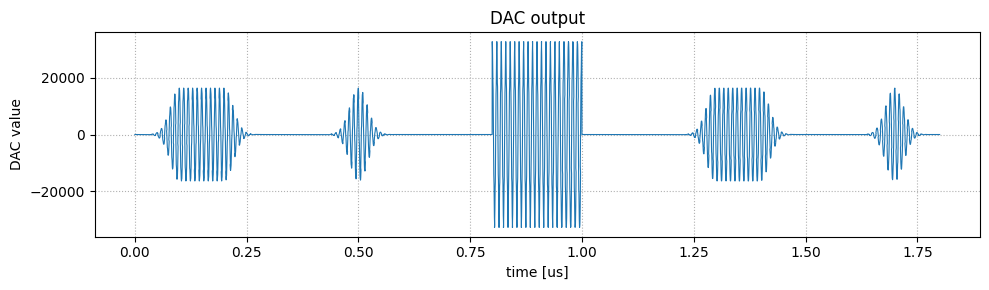

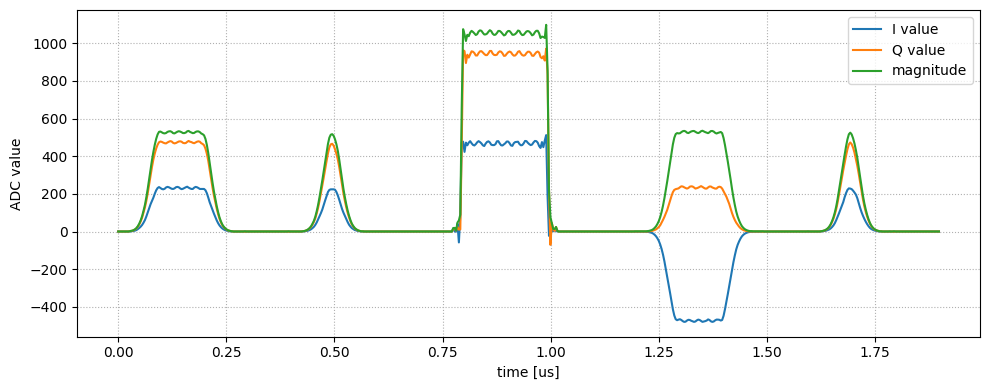

In [4]:
RUN_SIM = True

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=True)

    # DAC waveform — 16 parallel samples/clock are unrolled to a scope-like 1D
    # stream; gaps in axis_sg_dac_tvalid are preserved so distinct pulses show.
    t_dac, dac = emu.load_dac(OUT)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.xlabel("time [us]")
    plt.ylabel("DAC value")
    plt.title("DAC output")
    plt.grid(True, ls=":"); plt.tight_layout(); plt.show()

    # Decimated readout I/Q, same idiom as 00_intro.ipynb.
    iq_list = emu.load_iq_decimated(OUT, prog)
    t       = prog.get_time_axis(ro_index=0)

    plt.figure(figsize=(10, 4))
    plt.plot(t, iq_list[0][:, 0], label="I value")
    plt.plot(t, iq_list[0][:, 1], label="Q value")
    plt.plot(t, np.abs(iq_list[0].dot([1, 1j])), label="magnitude")
    plt.xlabel("time [us]")
    plt.ylabel("ADC value")
    plt.legend(); plt.grid(True, ls=":"); plt.tight_layout()
    plt.show()    


In [ ]:
print(prog)

In [ ]:
prog.print_pmem2hex()

---
## basic sweep program

A flat-top pulse with a swept phase and gain.

In [ ]:
class SimpleSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('myloop', cfg['steps'])

        self.add_gauss(
            ch=gen_ch,
            name='ramp',
            sigma=cfg['ramp_len'] / 10,
            length=cfg['ramp_len'],
            even_length=True
        )

        self.add_pulse(
            ch=gen_ch,
            name='mypulse',
            ro_ch=ro_ch,
            style='flat_top',
            envelope='ramp',
            freq=cfg['freq'],
            length=cfg['flat_len'],
            phase=cfg['phase'],
            gain=cfg['gain']
        )

        self.add_readoutconfig(
            ch=ro_ch,
            name='myro',
            freq=cfg['freq'],
            gen_ch=gen_ch
        )
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])


config = {
    'steps':     5,
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.35,
    'flat_len':  0.05,
    'ramp_len':  0.2,
    'phase':     QickSweep1D('myloop', -360, 720),
    'gain':      QickSweep1D('myloop',  0.0, 1.0),
}

# IMPORTANT
# Match the original hardware path
prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep'
OUT.mkdir(parents=True, exist_ok=True)

soc_emu = emu.make_soc(memdir=OUT)
prep = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

print(f'\nArtifacts → {OUT}')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name:<25s}  {f.stat().st_size:>8d} bytes')

### Simulate & plot (SimpleSweep)

In [ ]:
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

    # DAC waveform
    t_dac, dac = emu.load_dac(OUT)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.xlabel("time [us]")
    plt.ylabel("DAC value")
    plt.title("DAC output")
    plt.grid(True, ls=":")
    plt.tight_layout()
    plt.show()

    # Decimated IQ
    iq_list = emu.load_iq_decimated(OUT, prog)
    iq_steps = iq_list[0]

    # For reps=1 and one trigger, this should already be (steps, nsamp, 2)
    if iq_steps.ndim == 2:
        iq_steps = iq_steps[None, :, :]

    # Prefer the program time axis when lengths agree
    t = prog.get_time_axis(ro_index=0)
    if len(t) != iq_steps.shape[1]:
        # Fall back to a matching axis if emulator returned a shorter actual window
        ro_len_us = list(prog.ro_chs.values())[0]['length_us']
        t = np.linspace(0, ro_len_us, iq_steps.shape[1], endpoint=False)

    plt.figure(figsize=(10, 4))
    for ii, iq in enumerate(iq_steps):
        plt.plot(t, iq[:, 0], label=f"I value, step {ii}")
    plt.xlabel("us")
    plt.ylabel("a.u.")
    plt.legend()
    plt.grid(True, ls=":")
    plt.tight_layout()
    plt.show()

In [ ]:
print(prog)

---
## multi-dimensional loops and sweeps

Two user-defined loop levels on top of the reps loop.
The raw data shape will be `(reps, loop1, loop2)`.

In [ ]:
class Sweep2DProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('loop1', self.cfg['steps1'])  # outer
        self.add_loop('loop2', self.cfg['steps2'])  # inner

        self.add_gauss(ch=gen_ch, name='ramp', sigma=cfg['ramp_len']/10,
                       length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=cfg['flat_len'],
                       phase=cfg['phase'], gain=cfg['gain'])

        self.delay(0.5)
        self.trigger(ddr4=True, mr=True, t=0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        # --- FIXED: Shift the timeline forward slightly so DSP register updates can settle ---
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0.05)
        
        # Shift the readout trigger by the exact same amount to stay aligned
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'] + 0.05)
        
        self.delay_auto(0.01)

# --- FIXED: Crank the resolution back up for a smooth gradient ---
config = {
    'steps1':    10,  
    'steps2':    20,  
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.35,
    'flat_len':  0.05,
    'ramp_len':  0.2,
    'phase':     0,
    'gain':      0.4 + QickSpan("loop1", 0.5) + QickSpan("loop2", 0.1),
}

prog = Sweep2DProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# ── generate emulator artifacts ───────────────────────────────────────────────
OUT = ARTIFACTS_ROOT / 'sweep_2d'
OUT.mkdir(parents=True, exist_ok=True)

soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

print(f'\nArtifacts → {OUT}')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name:<25s}  {f.stat().st_size:>8d} bytes')

### Simulate & plot (Sweep2D)

In [ ]:
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

    # DAC waveform
    t_dac, dac = emu.load_dac(OUT)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.xlabel("time [us]"); plt.ylabel("DAC value"); plt.title("DAC output")
    plt.grid(True, ls=":"); plt.tight_layout(); plt.show()

    # 2D sweep
    iq_list = emu.load_iq_averaged(OUT, prog)
    print(f"iq_list[0].shape = {iq_list[0].shape}")   # <-- diagnostic
    print(f"loop_dims = {prog.loop_dims}, avg_level = {prog.avg_level}")
    print(f"ro_chs = {dict(prog.ro_chs)}")

    # Pick the last trig axis (the acquisition one, not the ddr4/mr setup trig).
    # iq_list[0] shape is (trigs, *loop_dims_after_avg, 2).
    iq_full = iq_list[0]
    if iq_full.ndim == 4:          # (trigs, loop1, loop2, 2) — expected
        iq = iq_full[-1]           # take the last trig (acquisition)
    elif iq_full.ndim == 3:        # (loop1, loop2, 2) — single trig
        iq = iq_full
    else:
        raise ValueError(f"unexpected iq shape {iq_full.shape}")

    mag = np.abs(iq.dot([1, 1j]))
    print(f"mag.shape = {mag.shape}")   # should be (10, 20)

    # (rest of the plotting code unchanged)
    mag_for_scale = mag.copy()
    mag_for_scale[0, 0] = np.nan
    mag_norm = mag / np.nanmax(mag_for_scale)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    p = axes[0]
    plt.colorbar(p.pcolormesh(mag_norm, vmin=0.4, vmax=1.0), ax=p)
    p.set_title("magnitude, actual"); p.set_ylabel("step index, loop 1"); p.set_xlabel("step index, loop 2")
    p = axes[1]
    expected_gain = prog.get_pulse_param("mypulse", "gain", as_array=True)
    plt.colorbar(p.pcolormesh(expected_gain, vmin=0.4, vmax=1.0), ax=p)
    p.set_title("magnitude, expected"); p.set_ylabel("step index, loop 1"); p.set_xlabel("step index, loop 2")
    plt.tight_layout(); plt.show()

In [ ]:
print(prog)

---
## understanding ASM and program structure

The cells below don't require a board — they just work against `soccfg` and demonstrate
different ways to write the same tProc program:
- text ASM (`Assembler`)
- ASM dicts (`QickProgramV2.asm_inst`)
- macro objects (`Waveform`, `ReadWmem`, …)
- macro methods (`.delay()`, `.read_wmem()`, …)

In [ ]:
from qick.tprocv2_assembler import Assembler

pstr = 'TIME #384 inc_ref\nREG_WR r_wave wmem [&0]\nWMEM_WR [&0]\n.END'
print('text ASM:')
print(pstr)

print('\nmachine code:')
for a in Assembler.str_asm2bin(pstr)[1]:
    print([hex(b) for b in a])

print('\nASM dicts:')
plist, labels = Assembler.str_asm2list(pstr)
for a in plist:
    print(a)
for a in labels.items():
    print(a)

print('\ntext ASM → ASM dicts → text ASM:')
print(Assembler.list2asm(plist, labels))

In [ ]:
from qick.asm_v2 import QickProgramV2

# Same program using asm_inst (ASM dict interface)
prog = QickProgramV2(soccfg)
prog.asm_inst({'CMD': 'TIME',    'C_OP': 'inc_ref', 'LIT': '#384'})
prog.asm_inst({'CMD': 'REG_WR',  'DST': 'r_wave',   'SRC': 'wmem', 'ADDR': '&0'})
prog.asm_inst({'CMD': 'WMEM_WR', 'DST': '[&0]'})
prog.end()

print('text ASM:')
print(prog.asm())
print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

In [ ]:
from qick.asm_v2 import QickProgramV2, Waveform, ReadWmem, WriteWmem, Delay

# Same program using macro objects
prog = QickProgramV2(soccfg)
prog.add_raw_pulse('mypulse', [Waveform(0, 0, 0, 0, 0, 0)])
prog.append_macro(Delay(t=1.0, auto=False))
for wname in prog.list_pulse_waveforms('mypulse'):
    prog.append_macro(ReadWmem(name=wname))
    prog.append_macro(WriteWmem(name=wname))
prog.end()

print('text ASM:')
print(prog.asm())
print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

In [ ]:
from qick.asm_v2 import QickProgramV2, Waveform

# Same program using macro methods (most common style)
prog = QickProgramV2(soccfg)
prog.add_raw_pulse('mypulse', [Waveform(0, 0, 0, 0, 0, 0)])
prog.delay(1.0)
for wname in prog.list_pulse_waveforms('mypulse'):
    prog.read_wmem(name=wname)
    prog.write_wmem(name=wname)
prog.end()

print('text ASM:')
print(prog.asm())
print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

---
## pulse updates and subroutines

Virtual-Z gate demo: same gate played four times with two π/2 virtual-Z rotations.
Uses a subroutine (`AsmV2` + `add_subroutine`) to avoid duplicating the update sequence.

In [ ]:
from qick.asm_v2 import AsmV2

class PulseUpdateProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.1
        self.add_gauss(ch=gen_ch, name='ramp', sigma=ramp_len/10,
                       length=ramp_len, even_length=True)
        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.05, phase=0, gain=1.0)

        # subroutine: add 90 degrees to the phase of myflattop
        sub = AsmV2()
        for wname in self.list_pulse_waveforms('myflattop'):
            sub.read_wmem(name=wname)
            sub.inc_reg(dst='w_phase', src=self.deg2reg(90, gen_ch=gen_ch))
            sub.write_wmem(name=wname)
        self.add_subroutine('virt_z', sub)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.2)
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.4)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.6)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.9,
}

prog = PulseUpdateProgram(soccfg, reps=2, final_delay=0.5, cfg=config)

# ── generate emulator artifacts ───────────────────────────────────────────────
OUT = ARTIFACTS_ROOT / 'pulse_update'
OUT.mkdir(parents=True, exist_ok=True)

soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

print(f'\nArtifacts → {OUT}')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name:<25s}  {f.stat().st_size:>8d} bytes')

### Simulate & plot (PulseUpdate)

In [ ]:
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

    # DAC waveform — 16 parallel samples/clock are unrolled to a scope-like 1D
    # stream; gaps in axis_sg_dac_tvalid are preserved so distinct pulses show.
    t_dac, dac = emu.load_dac(OUT)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.xlabel("time [us]")
    plt.ylabel("DAC value")
    plt.title("DAC output")
    plt.grid(True, ls=":"); plt.tight_layout(); plt.show()

    # PulseUpdate runs `reps` copies of the body; iq_list[0] is (reps, length, 2).
    iq_list = emu.load_iq_decimated(OUT, prog)
    t       = prog.get_time_axis(ro_index=0)

    # Safely handle dimensions
    data = iq_list[0] if iq_list[0].ndim == 3 else iq_list[0][None, ...]
    
    fig, axes = plt.subplots(len(data), 1, figsize=(10, 6))
    
    # Handle edge case if reps=1 so axes is always iterable
    if len(data) == 1:
        axes = [axes]

    for ii, rep in enumerate(data):
        plot = axes[ii]

        plot.plot(t, rep[:, 0], label="I value")
        plot.plot(t, rep[:, 1], label="Q value")
        plot.plot(t, np.abs(rep.dot([1, 1j])), label="magnitude") # Added magnitude back!
        
        plot.legend()
        plot.set_title(f"rep {ii}")
        plot.set_ylabel("a.u.")
        plot.set_xlabel("us")
        plot.set_ylim(-650, 650)
        
    plt.tight_layout()
    plt.show()

In [ ]:
print(prog)

---
## Inspect AXI replay & simulation outputs

Useful to verify what register writes will be replayed by the TB,
or to re-plot results from a previous run without re-simulating.

In [ ]:
# Show the AXI replay for the last artifact directory generated above
replay_txt = OUT / 'axi_replay.txt'
if replay_txt.exists():
    print(f'=== {replay_txt} ===')
    with replay_txt.open() as f:
        for i, line in enumerate(f):
            print(line, end='')
            if i > 30:
                print(f'... ({sum(1 for _ in replay_txt.open()) - i - 1} more lines)')
                break

In [ ]:
# Re-plot results from any artifact directory without re-simulating
# (just change OUT to the desired directory).
t_dac, dac = emu.load_dac(OUT)
plt.figure(figsize=(10, 3))
plt.plot(t_dac, dac, linewidth=0.8)
plt.xlabel("time [us]")
plt.ylabel("DAC value")
plt.title("DAC output")
plt.grid(True, ls=":"); plt.tight_layout(); plt.show()

iq_list = emu.load_iq_decimated(OUT, prog)
t       = prog.get_time_axis(ro_index=0)

data = iq_list[0] if iq_list[0].ndim == 3 else iq_list[0][None, ...]
plt.figure(figsize=(10, 4))
for ii, rep in enumerate(data):
    plt.plot(t, rep[:, 0], label=f"I (step/rep {ii})")
plt.xlabel("time [us]")
plt.ylabel("ADC value")
plt.legend(); plt.grid(True, ls=":"); plt.tight_layout()
plt.show()
